## Dataset

https://pytorch-geometric.readthedocs.io/en/2.5.3/generated/torch_geometric.datasets.AmazonProducts.html

### Training Approach

-This dataset is significantly larger and won't fit in memory, so we will leverage neighorloader to sample the graph during training

-We would also need to clear embeddings,clear cuda cache and enable garbage collection whenever needed

In [1]:
import os
import gc
from torch_geometric.datasets import AmazonProducts
from torch_geometric.loader import NeighborLoader
import torch
import numpy as np

In [2]:
root_dir = './data/AmazonProducts'

In [3]:
print("Loading AmazonProducts (1.5M nodes)...")
dataset = AmazonProducts(root=root_dir)
data = dataset[0]

print(f"--- Dataset Statistics ---")
print(f"Nodes: {data.num_nodes:,}")
print(f"Edges: {data.num_edges:,}")
print(f"Features: {data.num_node_features}")
print(f"Classes: {dataset.num_classes}")

Loading AmazonProducts (1.5M nodes)...
--- Dataset Statistics ---
Nodes: 1,569,960
Edges: 264,339,468
Features: 200
Classes: 107


## Graph Stats

### Structural Profiling

In [4]:
print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Features: {data.num_node_features}")
print(f"Classes: {dataset.num_classes}")
print(f"Avg node degree {data.num_edges / data.num_nodes}")

Nodes: 1569960
Edges: 264339468
Features: 200
Classes: 107
Avg node degree 168.37337766567302


In [4]:
import matplotlib.pyplot as plt

/home/y/anaconda3/envs/gnn/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/y/anaconda3/envs/gnn/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


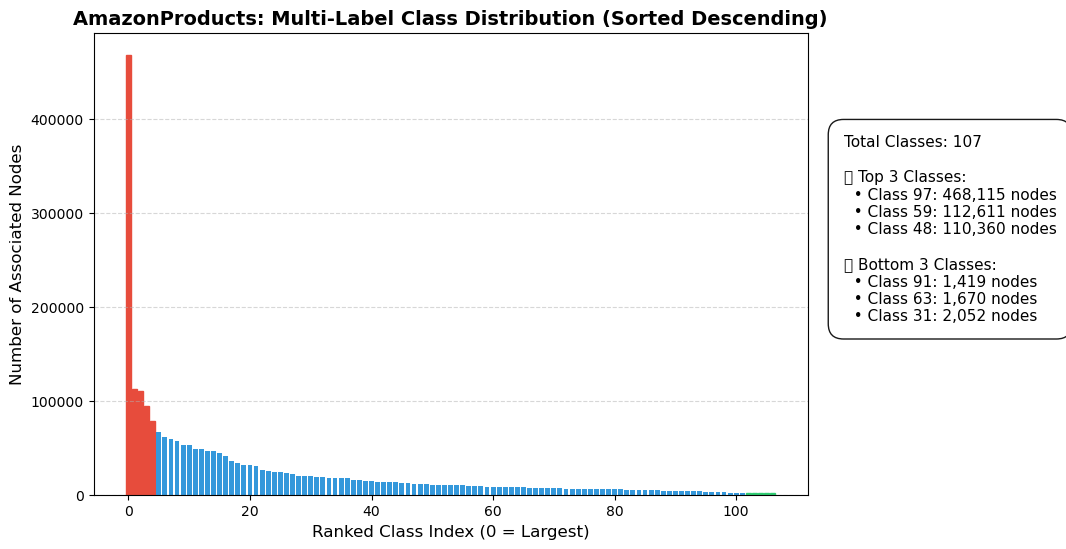

In [6]:
# 1. Compute counts and convert to a sorted numpy array
class_counts = data.y.sum(dim=0).cpu().numpy()
sorted_indices = np.argsort(class_counts)[::-1]  # Sort descending
sorted_counts = class_counts[sorted_indices]

# 2. Build the visual plot
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(sorted_counts)), sorted_counts, color='#3498db', edgecolor='none', width=0.8)

# Stylize majority and minority classes distinctly
for idx in range(5):
    bars[idx].set_color('#e74c3c')     # Red for the Top 5 massive classes
for idx in range(-5, 0):
    bars[idx].set_color('#2ecc71')    # Green for the Bottom 5 tiny classes

# 3. Create a descriptive, informative legend text block
legend_text = (
    f"Total Classes: {len(class_counts)}\n\n"
    f"🔴 Top 3 Classes:\n"
    f"  • Class {sorted_indices[0]}: {int(sorted_counts[0]):,} nodes\n"
    f"  • Class {sorted_indices[1]}: {int(sorted_counts[1]):,} nodes\n"
    f"  • Class {sorted_indices[2]}: {int(sorted_counts[2]):,} nodes\n\n"
    f"🟢 Bottom 3 Classes:\n"
    f"  • Class {sorted_indices[-1]}: {int(sorted_counts[-1]):,} nodes\n"
    f"  • Class {sorted_indices[-2]}: {int(sorted_counts[-2]):,} nodes\n"
    f"  • Class {sorted_indices[-3]}: {int(sorted_counts[-3]):,} nodes"
)

# 4. Final Plot Styling
plt.title("AmazonProducts: Multi-Label Class Distribution (Sorted Descending)", fontsize=14, fontweight='bold')
plt.xlabel("Ranked Class Index (0 = Largest)", fontsize=12)
plt.ylabel("Number of Associated Nodes", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Place the textual breakdown clearly on the right side of the canvas
plt.gcf().text(0.75, 0.4, legend_text, fontsize=11, bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=1'))
plt.subplots_adjust(right=0.72)

plt.show()

### Quick Intepretation of Results

-The dataset is heavily imbalanced (~400x ratio between mean and max classes) but it's also multi-labeled so we have to use a different performance metric (maybe BCEWithLogitsLoss)

-Average node degree (107) so there's high risk of completely drowning the weak featured nodes

In [5]:
import mlflow

In [6]:
DB_NAME = "mlflow_amazon_products.db"
mlflow.set_tracking_uri(f"sqlite:///{DB_NAME}")
mlflow.set_experiment("Amazon_Products_Large_Scale_Training")

<Experiment: artifact_location='/home/y/Desktop/notebooks/GNN-XGBoost-Recommendation/mlruns/1', creation_time=1779307492907, experiment_id='1', last_update_time=1779307492907, lifecycle_stage='active', name='Amazon_Products_Large_Scale_Training', tags={}, trace_location=None, workspace='default'>

## Baseline Model

Let's start with a model to establish a baseline. Since we're training a large scale graph we can't load the full graph in memory and we'll need an architecture that enables sampling. We'll start with GraphSage since it checks all the boxes above and also allows us to use node features beside the graph topology which we'll need for this example.

We'll start with two SAGEConv layers with the naive assumption that two hop neighbors contain enough information . 

For the final classifier we'll use two mlp layers to project the initial embeddings down to class scores

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

In [10]:
class GraphSAGEWithMLPHead(nn.Module):
    def __init__(self, in_feats, hidden_feats, embedding_dim, num_classes):
        super().__init__()
        self.conv1 = SAGEConv(in_feats, hidden_feats, root_weight=True)
        self.conv2 = SAGEConv(hidden_feats, embedding_dim, root_weight=True)
        
        self.mlp1 = nn.Linear(embedding_dim, 128)
        self.dropout = nn.Dropout(0.3)
        self.mlp2 = nn.Linear(128, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        x = self.mlp1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.mlp2(x)
        return x

Since the dataset is severly imbalanced, we can't just use random split on node or edge sampling. We'll instead use a stratified method that allows to train on as close of a sample as we can to the graph without loosing any weak labels. 

We can't use ready made methods because they will choke on the size of this graph so we'll need a custom method that can also handle the multi-label aspect of this data

The following method solves this by assigning each multi-label node to its single rarest active class, then uses standard stratification to ensure rare classes are not accidentally erased from the smaller subset.

In [8]:
from torch_geometric.loader import NeighborLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score

In [9]:
def create_stratified_train_mask(data, sample_ratio=0.10):
    """
    Applies a high-performance rarest-label heuristic to stratify 
    the 107-class multi-label space without a memory blowout.
    """
    print(f"Extracting a {sample_ratio*100:.1f}% stratified subset from the training mask...")
    
    # Isolate original train node indices
    train_idx = data.train_mask.nonzero(as_tuple=False).view(-1)
    y_train = data.y[train_idx]
    
    # Step 1: Calculate global label frequencies across the training pool
    label_frequencies = y_train.sum(dim=0)
    # Avoid division-by-zero errors for unrepresented categories
    label_frequencies = torch.where(label_frequencies == 0, torch.ones_like(label_frequencies), label_frequencies)
    inverse_frequencies = 1.0 / label_frequencies
    
    # Step 2: Map each node's active multi-label array to its rarest label representation
    node_label_weights = y_train * inverse_frequencies.unsqueeze(0)
    
    # Tag nodes that contain no active labels with a dummy fallback class index (107)
    has_labels = (y_train.sum(dim=1) > 0)
    rarest_label_per_node = torch.where(
        has_labels, 
        node_label_weights.argmax(dim=1), 
        torch.tensor(107, device=y_train.device)
    ).cpu().numpy()
    
    # Step 3: Run class-proportionate stratified sampling over the mapped targets
    stratifier = StratifiedShuffleSplit(n_splits=1, train_size=sample_ratio, random_state=42)
    train_idx_np = train_idx.cpu().numpy()
    
    stratified_sample_indices = []
    for sample_idx, _ in stratifier.split(np.zeros(len(rarest_label_per_node)), rarest_label_per_node):
        stratified_sample_indices = train_idx_np[sample_idx]
        
    # Step 4: Construct the optimized train mask array
    stratified_train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    stratified_train_mask[torch.tensor(stratified_sample_indices, dtype=torch.long)] = True
    
    print(f"Stratification complete! Training node footprint optimized from {len(train_idx):,} down to {len(stratified_sample_indices):,}")
    return stratified_train_mask

### Metrics 

Let's start with a BCEWithLogitsLoss for a loss function and adam as an optimizer.

Since average node degree is significant, we'll start with a 10% sample. Learned this the hard way after starting with a larger sample and have pulled 10 neighbors for the first hop and 15 for the second hope for 100k nodes and their 168 friends which led to digging into SWAP memory

For the success metric we'll pick Macro F1 so can properly evaluate the imbalance and not be fooled by accuracy

In [10]:
import gc
import torch

def clear_gnn_training_memory(loader=None):
    """
    Completely flushes CPU/GPU memory caches, forces garbage collection, 
    and explicitly tears down PyG NeighborLoader background workers.
    
    Args:
        loader (NeighborLoader, optional): The PyG DataLoader used during training.
    """
    print("\n--- Initiating Post-Training Memory Clean Up ---")
    
    # 1. Force close background multiprocess workers if persistent_workers=True
    if loader is not None:
        print("Shutting down active DataLoader worker processes...")
        try:
            # Safely attempt to kill worker threads/processes
            if hasattr(loader, '_iterator') and loader._iterator is not None:
                loader._iterator._shutdown_workers()
                loader._iterator = None
        except Exception as e:
            print(f"Note: Safe worker shutdown bypassed ({e})")

    # 2. Clear out Python's references
    # This ensures any hidden tensors or graph objects lingering in local scope are collected
    gc.collect()

    # 3. Flush PyTorch's internal memory allocators
    if torch.cuda.is_available():
        print(f"CUDA Memory Allocated Before: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        print(f"CUDA Memory Allocated After: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    else:
        print("No CUDA device detected; skipped GPU cache flush.")

    print("Memory cleanup complete.\n")

In [14]:
def train_stratified_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


    #Load data
    print("Loading official AmazonProducts graph data...")
    dataset = AmazonProducts(root='./data/AmazonProducts')
    data = dataset[0]
    
    #Generate custom stratified mask
    stratified_mask = create_stratified_train_mask(data, sample_ratio=0.10)
    

    #Train and val neighbor loader
    train_loader = NeighborLoader(
        data,
        num_neighbors=[15, 10],
        batch_size=512,
        input_nodes=stratified_mask,
        shuffle=True,
        num_workers=4,
        persistent_workers=True #Learned this the hard way after a kernel shutdown. This keeps CPU from crashing since it doesn't have to spawn workers between epochs
    )

    val_loader = NeighborLoader(
        data,
        num_neighbors=[15, 10],
        batch_size=512,
        input_nodes=data.val_mask,
        shuffle=False,
        num_workers=8,
        persistent_workers=True
    )

    model = GraphSAGEWithMLPHead(
        in_feats=dataset.num_features,
        hidden_feats=256,
        embedding_dim=128,
        num_classes=dataset.num_classes
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)

    with mlflow.start_run(run_name="Stratified_10_Percent_SAGE_Run"):
        mlflow.log_param("architecture", "GraphSAGE_MLP_Stratified")
        mlflow.log_param("stratification_sampling_ratio", 0.10)
        mlflow.log_param("mlflow_backend_db", DB_NAME)

        epochs = 10
        for epoch in range(epochs):
            model.train()
            total_train_loss = 0.0
            total_train_batches = 0
            
            print(f"\n--- Starting Stratified Training Epoch {epoch + 1}/{epochs} ---")
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                
                logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                targets = batch.y[:batch.batch_size].float()
                
                loss = criterion(logits, targets)
                loss.backward()
                optimizer.step()
                
                total_train_loss += loss.item()
                total_train_batches += 1

            avg_train_loss = total_train_loss / total_train_batches

            
            model.eval()
            total_val_loss = 0.0
            total_val_batches = 0
            all_preds, all_targets = [], []

            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                    targets = batch.y[:batch.batch_size].float()
                    
                    val_loss = criterion(logits, targets)
                    total_val_loss += val_loss.item()
                    total_val_batches += 1
                    
             
                    preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
                    all_preds.append(preds)
                    all_targets.append(targets.cpu().numpy())

            avg_val_loss = total_val_loss / total_val_batches
            all_preds = np.concatenate(all_preds, axis=0)
            all_targets = np.concatenate(all_targets, axis=0)
            
            
            macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

            
            mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
            mlflow.log_metric("val_macro_f1", macro_f1, step=epoch)
            
            print(f"Epoch {epoch+1} | Stratified Train Loss: {avg_train_loss} | Val Loss: {avg_val_loss} | Val Macro F1: {macro_f1}")

        torch.save(model.state_dict(), "stratified_sage_mlp.pt")
        mlflow.log_artifact("stratified_sage_mlp.pt")


        #Cleaning mem
        del model
        
        # Pass the loaders into our cleanup function to terminate background workers
        clear_gnn_training_memory(loader=train_loader)
        clear_gnn_training_memory(loader=val_loader)
        
        del train_loader, val_loader
        gc.collect()

In [15]:
train_stratified_pipeline()

Loading official AmazonProducts graph data...
Extracting a 10.0% stratified subset from the training mask...
Stratification complete! Training node footprint optimized from 1,255,968 down to 125,596

--- Starting Stratified Training Epoch 1/10 ---
Epoch 1 | Stratified Train Loss: 0.08913382806065606 | Val Loss: 0.05991706786701431 | Val Macro F1: 0.007136599654952991

--- Starting Stratified Training Epoch 2/10 ---
Epoch 2 | Stratified Train Loss: 0.05302024205646864 | Val Loss: 0.043383425875724135 | Val Macro F1: 0.04646128634279291

--- Starting Stratified Training Epoch 3/10 ---
Epoch 3 | Stratified Train Loss: 0.039324222117420135 | Val Loss: 0.03361370765253321 | Val Macro F1: 0.12986589294542067

--- Starting Stratified Training Epoch 4/10 ---
Epoch 4 | Stratified Train Loss: 0.0328738881214484 | Val Loss: 0.03004087279127403 | Val Macro F1: 0.18408459416745765

--- Starting Stratified Training Epoch 5/10 ---
Epoch 5 | Stratified Train Loss: 0.02976185645968691 | Val Loss: 0.028

### Results Interpretation and next steps

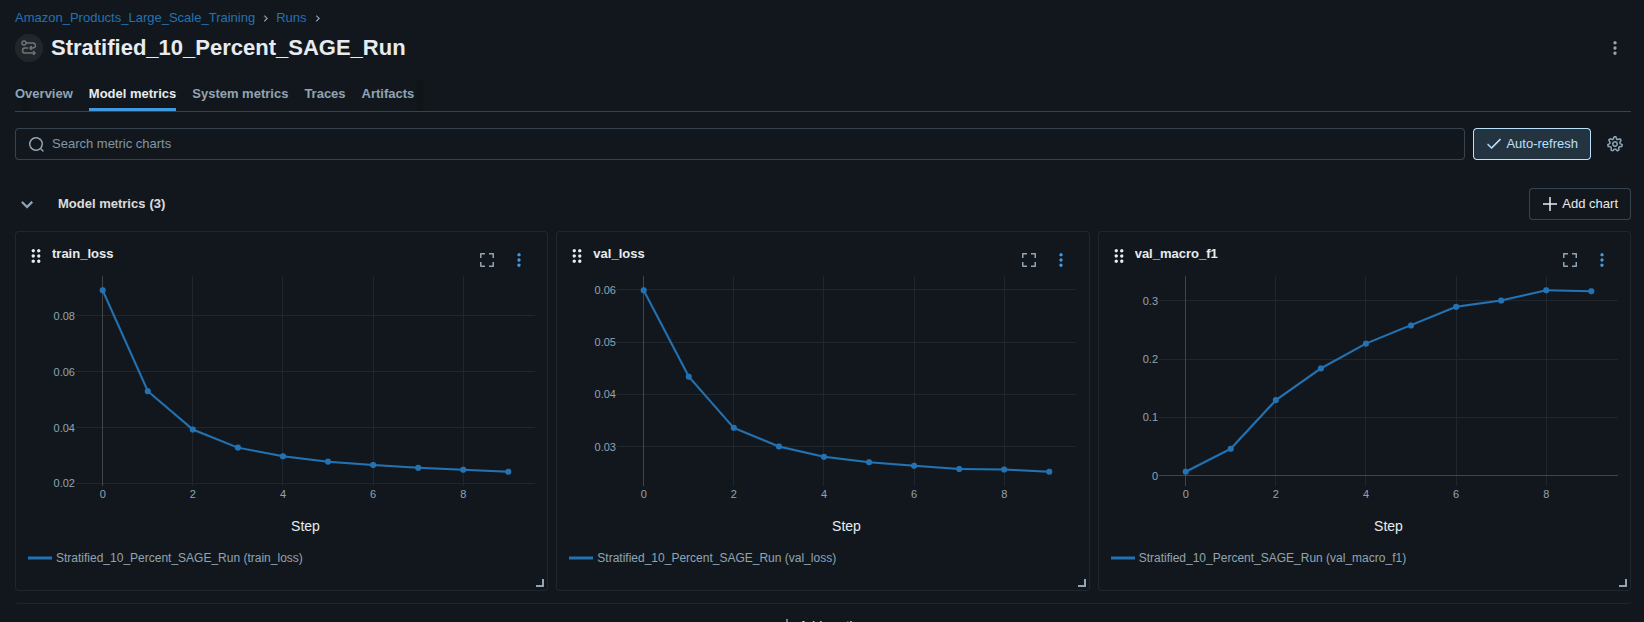

Good stability on training and validation loss curves but the macro f1 is staring to plateau at 0.31 on epoch 8 which points to the model not learning. This maybe an issue with the fact that there's a lot of background noise from the multi-label aspect of this data. 

Let's change the loss function to a method that calibrates weights properly. Assymetric Loss is a good start.

## Updating the Loss Function

In [11]:
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        xs_p = torch.sigmoid(logits)
        xs_n = 1.0 - xs_p
        if self.clip and self.clip > 0:
            xs_n = (xs_n + self.clip).clamp(max=1.0)
        loss_pos = targets * torch.log(xs_p.clamp(min=self.eps)) * (1.0 - xs_p).pow(self.gamma_pos)
        loss_neg = (1.0 - targets) * torch.log(xs_n.clamp(min=self.eps)) * (1.0 - xs_n).pow(self.gamma_neg)
        return -(loss_pos + loss_neg).mean()

Let's also tune the learning rate a bit and use a scheduler like CosineAnnealing

Let's also optimize the macro f1 per class on a range between 0.05 and 0.95, making sure that we setup a wide range of thresholds for all labels

In [17]:
def train_optimized_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = AmazonProducts(root='./data/AmazonProducts')
    data = dataset[0]
    
    stratified_mask = create_stratified_train_mask(data, sample_ratio=0.10)
    
    
    train_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=stratified_mask,
        shuffle=True, num_workers=4, persistent_workers=True
    )
    val_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=data.val_mask,
        shuffle=False, num_workers=4, persistent_workers=True
    )

    model = GraphSAGEWithMLPHead(dataset.num_features, 256, 128, dataset.num_classes).to(device)
    criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
    
    # LR scheduler
    epochs = 15 
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    with mlflow.start_run(run_name="Optimized_15_Epoch_ASL_Run"):
        mlflow.log_param("architecture", "GraphSAGE_MLP_ASL")
        mlflow.log_param("loss_function", "AsymmetricLoss")
        
        for epoch in range(epochs):
            model.train()
            total_train_loss = 0.0
            total_train_batches = 0
            
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                loss = criterion(logits, batch.y[:batch.batch_size].float())
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()
                total_train_batches += 1

            scheduler.step()
            avg_train_loss = total_train_loss / total_train_batches

            # val loop
            model.eval()
            total_val_loss = 0.0
            total_val_batches = 0
            all_logits, all_targets = [], []

            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                    targets = batch.y[:batch.batch_size].float()
                    
                    val_loss = criterion(logits, targets)
                    total_val_loss += val_loss.item()
                    total_val_batches += 1
                    
                    all_logits.append(logits.cpu())
                    all_targets.append(targets.cpu())

            avg_val_loss = total_val_loss / total_val_batches
            all_logits = torch.cat(all_logits, dim=0)
            all_targets = torch.cat(all_targets, dim=0)
            
        
            baseline_preds = (torch.sigmoid(all_logits) >= 0.5).int().numpy()
            macro_f1 = f1_score(all_targets.numpy(), baseline_preds, average='macro', zero_division=0)

            mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
            mlflow.log_metric("val_macro_f1", macro_f1, step=epoch)
            mlflow.log_metric("learning_rate", scheduler.get_last_lr()[0], step=epoch)
            
            print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss} | Val Loss: {avg_val_loss} | Val Macro F1 [0.5 Threshold]: {macro_f1}")

        # Threshold tuning
        probs = torch.sigmoid(all_logits).numpy()
        targets_np = all_targets.numpy()
        best_thresholds = np.full(dataset.num_classes, 0.5)
        
        for c in range(dataset.num_classes):
            best_class_f1 = 0.0
            for t in np.linspace(0.05, 0.95, 19):
                preds = (probs[:, c] >= t).astype(int)
                f1 = f1_score(targets_np[:, c], preds, zero_division=0)
                if f1 > best_class_f1:
                    best_class_f1 = f1
                    best_thresholds[c] = t
                    
        # Apply best thresholds
        optimized_preds = (probs >= best_thresholds).astype(int)
        optimized_macro_f1 = f1_score(targets_np, optimized_preds, average='macro', zero_division=0)
        
        mlflow.log_metric("optimized_final_macro_f1", optimized_macro_f1)
        print(f"\nFinal Optimized Macro F1: {optimized_macro_f1:.4f} (Upgraded from baseline {macro_f1:.4f})")

        torch.save(model.state_dict(), "optimized_sage_asl.pt")
        mlflow.log_artifact("optimized_sage_asl.pt")

        #Cleaning mem
        del model
        
        # Pass the loaders into our cleanup function to terminate background workers
        clear_gnn_training_memory(loader=train_loader)
        clear_gnn_training_memory(loader=val_loader)
        
        del train_loader, val_loader
        gc.collect()

if __name__ == "__main__":
    train_optimized_pipeline()

Extracting a 10.0% stratified subset from the training mask...
Stratification complete! Training node footprint optimized from 1,255,968 down to 125,596
Epoch 1 | Train Loss: 0.009503753615422099 | Val Loss: 0.006450262310757459 | Val Macro F1 [0.5 Threshold]: 0.19772623705761538
Epoch 2 | Train Loss: 0.005930516565960597 | Val Loss: 0.005270631844782597 | Val Macro F1 [0.5 Threshold]: 0.31163791252612455
Epoch 3 | Train Loss: 0.005188267312686496 | Val Loss: 0.004891700422778339 | Val Macro F1 [0.5 Threshold]: 0.3683547300332052
Epoch 4 | Train Loss: 0.004832292749826622 | Val Loss: 0.004749894916237175 | Val Macro F1 [0.5 Threshold]: 0.39816488343715806
Epoch 5 | Train Loss: 0.004602207912972606 | Val Loss: 0.004588584651469023 | Val Macro F1 [0.5 Threshold]: 0.42150059995102696
Epoch 6 | Train Loss: 0.00444906101584798 | Val Loss: 0.004481234085782395 | Val Macro F1 [0.5 Threshold]: 0.44185827805645056
Epoch 7 | Train Loss: 0.004265524782013239 | Val Loss: 0.004391474094447474 | Val

### Results Interpretation and next steps

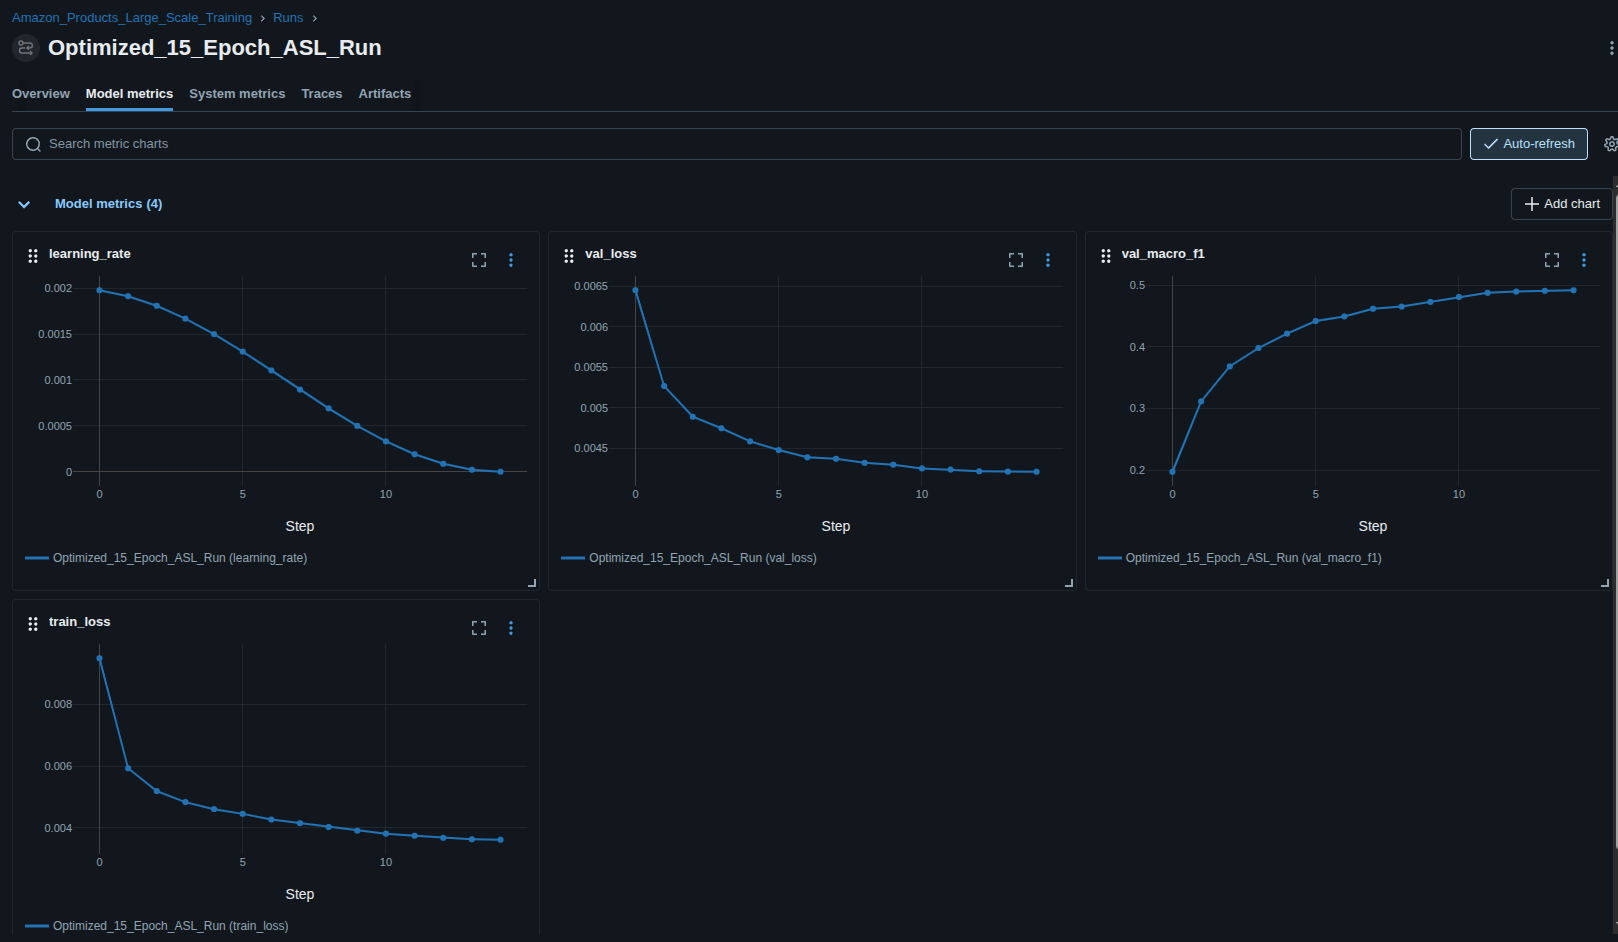

Updating Loss function worked. We were able to go from a 0.31 macro f1 score to 0.52 including training on more epochs, adding the LR scheduler and a slight increase on the f1 score from the post training thresholding per class 

I wonder if we can squeeze more out of this architecture if we add skip connections. This would work for the gradients of the nodes that are being drowned with the massive 168 neighbors embeddings.

## Skip Connections?

In [10]:
class GraphSAGEWithSkipConnections(nn.Module):
    def __init__(self, in_feats, hidden_feats, embedding_dim, num_classes):
        super().__init__()
        self.conv1 = SAGEConv(in_feats, hidden_feats, root_weight=True)
        self.conv2 = SAGEConv(hidden_feats, embedding_dim, root_weight=True)
        
        self.input_skip_projector = nn.Linear(in_feats, embedding_dim)
        self.layer1_skip_projector = nn.Linear(hidden_feats, embedding_dim)
        
        self.mlp1 = nn.Linear(embedding_dim, 128)
        self.dropout = nn.Dropout(0.3)
        self.mlp2 = nn.Linear(128, num_classes)

    def forward(self, x, edge_index):
        # Layer 1
        h1 = F.relu(self.conv1(x, edge_index))
        
        # Layer 2 with residual from Layer 1
        h2 = F.relu(self.conv2(h1, edge_index))
        h2 = h2 + self.layer1_skip_projector(h1)
        
        # Last layer with residual from input features
        embeddings = F.relu(h2 + self.input_skip_projector(x))
        
        # Classification
        out = F.relu(self.mlp1(embeddings))
        return self.mlp2(self.dropout(out))


In [22]:
def train_residual_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = AmazonProducts(root='./data/AmazonProducts')
    data = dataset[0]
    
    stratified_mask = create_stratified_train_mask(data, sample_ratio=0.10)
    
    train_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=stratified_mask,
        shuffle=True, num_workers=4, persistent_workers=True
    )
    val_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=data.val_mask,
        shuffle=False, num_workers=4, persistent_workers=True
    )

    model = GraphSAGEWithSkipConnections(dataset.num_features, 256, 128, dataset.num_classes).to(device)
    criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
    
    epochs = 15 
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    with mlflow.start_run(run_name="Residual_Skip_Connections_ASL_Run"):
        mlflow.log_param("architecture", "GraphSAGE_Residual_MLP_ASL")
        mlflow.log_param("loss_function", "AsymmetricLoss")
        
        for epoch in range(epochs):
            model.train()
            total_train_loss = 0.0
            total_train_batches = 0
            
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                loss = criterion(logits, batch.y[:batch.batch_size].float())
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()
                total_train_batches += 1

            scheduler.step()
            avg_train_loss = total_train_loss / total_train_batches

            model.eval()
            total_val_loss = 0.0
            total_val_batches = 0
            all_logits, all_targets = [], []

            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                    targets = batch.y[:batch.batch_size].float()
                    
                    val_loss = criterion(logits, targets)
                    total_val_loss += val_loss.item()
                    total_val_batches += 1
                    
                    all_logits.append(logits.cpu())
                    all_targets.append(targets.cpu())

            avg_val_loss = total_val_loss / total_val_batches
            all_logits = torch.cat(all_logits, dim=0)
            all_targets = torch.cat(all_targets, dim=0)
            
            baseline_preds = (torch.sigmoid(all_logits) >= 0.5).int().numpy()
            macro_f1 = f1_score(all_targets.numpy(), baseline_preds, average='macro', zero_division=0)

            mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
            mlflow.log_metric("val_macro_f1", macro_f1, step=epoch)
            mlflow.log_metric("learning_rate", scheduler.get_last_lr()[0], step=epoch)
            
            print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Macro F1 [0.5 Threshold]: {macro_f1:.4f}")

        print("\nTuning optimal per-class decision thresholds...")
        probs = torch.sigmoid(all_logits).numpy()
        targets_np = all_targets.numpy()
        best_thresholds = np.full(dataset.num_classes, 0.5)
        
        for c in range(dataset.num_classes):
            best_class_f1 = 0.0
            for t in np.linspace(0.05, 0.95, 19):
                preds = (probs[:, c] >= t).astype(int)
                f1 = f1_score(targets_np[:, c], preds, zero_division=0)
                if f1 > best_class_f1:
                    best_class_f1 = f1
                    best_thresholds[c] = t
                    
        optimized_preds = (probs >= best_thresholds).astype(int)
        optimized_macro_f1 = f1_score(targets_np, optimized_preds, average='macro', zero_division=0)
        
        mlflow.log_metric("optimized_final_macro_f1", optimized_macro_f1)
        print(f"\nFinal Optimized Macro F1: {optimized_macro_f1:.4f} (Baseline: {macro_f1:.4f})")

        torch.save(model.state_dict(), "residual_sage_asl.pt")
        mlflow.log_artifact("residual_sage_asl.pt")


        #Cleaning mem
        del model
        
        # Pass the loaders into our cleanup function to terminate background workers
        clear_gnn_training_memory(loader=train_loader)
        clear_gnn_training_memory(loader=val_loader)
        
        del train_loader, val_loader
        gc.collect()

In [23]:
train_residual_pipeline()

Extracting a 10.0% stratified subset from the training mask...
Stratification complete! Training node footprint optimized from 1,255,968 down to 125,596
Epoch 01 | Train Loss: 0.0088 | Val Loss: 0.0059 | Val Macro F1 [0.5 Threshold]: 0.2691
Epoch 02 | Train Loss: 0.0055 | Val Loss: 0.0049 | Val Macro F1 [0.5 Threshold]: 0.3770
Epoch 03 | Train Loss: 0.0049 | Val Loss: 0.0046 | Val Macro F1 [0.5 Threshold]: 0.4228
Epoch 04 | Train Loss: 0.0046 | Val Loss: 0.0045 | Val Macro F1 [0.5 Threshold]: 0.4519
Epoch 05 | Train Loss: 0.0043 | Val Loss: 0.0043 | Val Macro F1 [0.5 Threshold]: 0.4728
Epoch 06 | Train Loss: 0.0042 | Val Loss: 0.0043 | Val Macro F1 [0.5 Threshold]: 0.4857
Epoch 07 | Train Loss: 0.0040 | Val Loss: 0.0042 | Val Macro F1 [0.5 Threshold]: 0.4969
Epoch 08 | Train Loss: 0.0038 | Val Loss: 0.0042 | Val Macro F1 [0.5 Threshold]: 0.5094
Epoch 09 | Train Loss: 0.0037 | Val Loss: 0.0041 | Val Macro F1 [0.5 Threshold]: 0.5156
Epoch 10 | Train Loss: 0.0036 | Val Loss: 0.0041 | Val 

### Results Interpretation and next steps

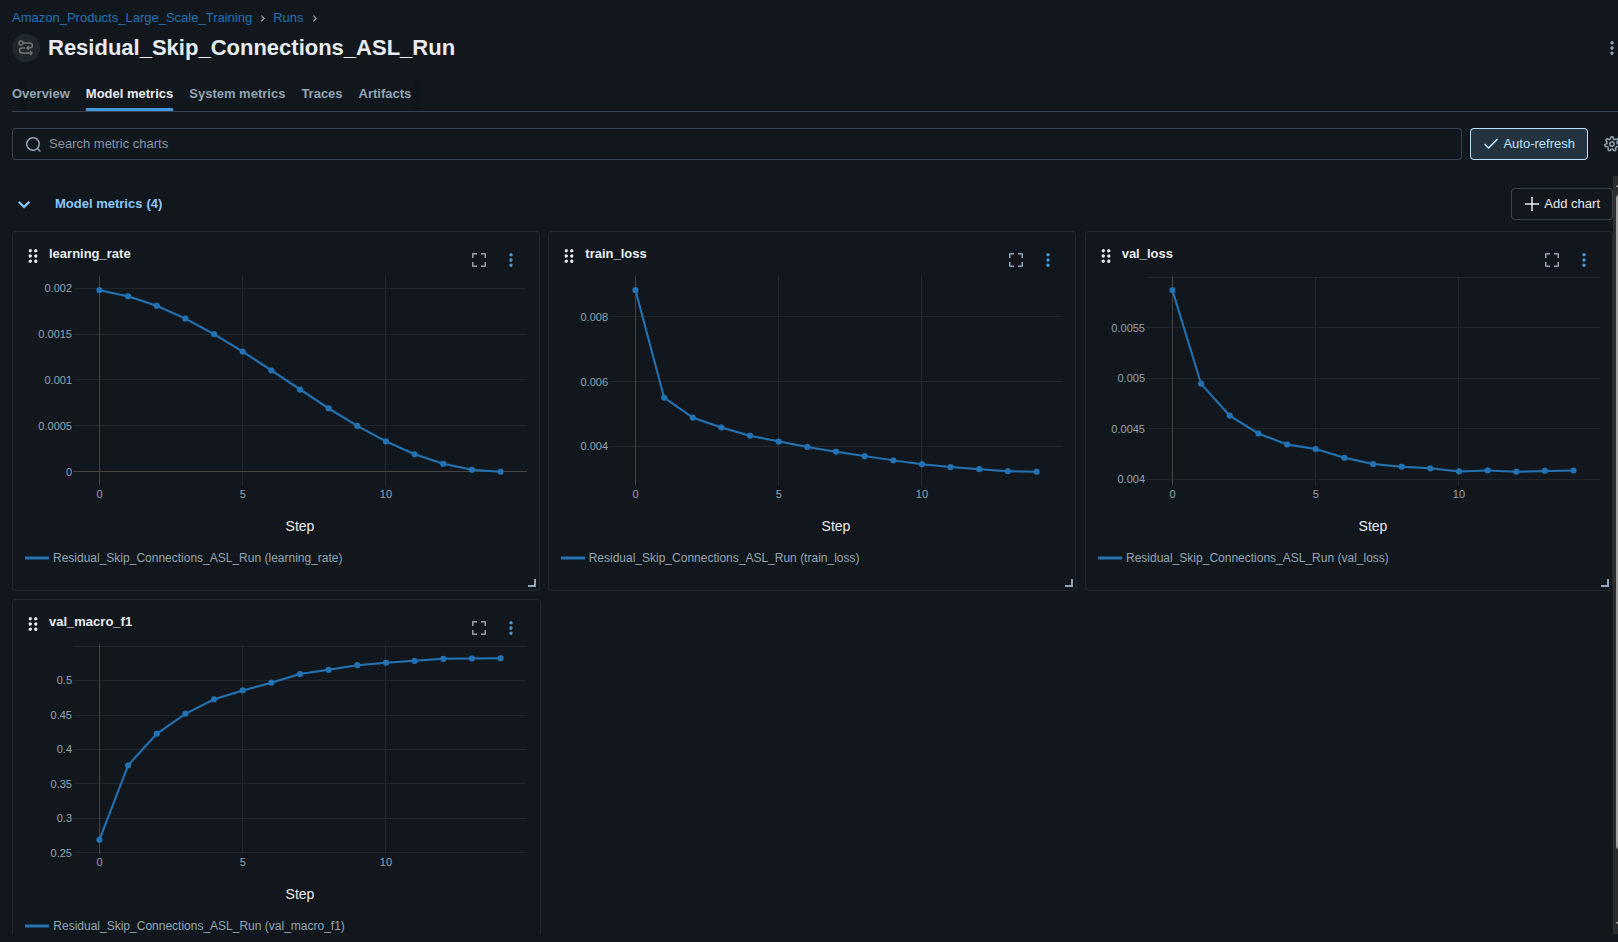

- Slightly better F1 macro score (we went from 0.52 to 0.55) but this might also signal that we have reached the limits of our 2 layer GraphSage model. Maybe data augmentation or helping the model to understand the data better.

- Since the dataset has 107 labels and products can belong to multiple labels I wonder if there's correlation betweeen the labels that the model can learn and use. Let's add a new layer to our model that can leverage these correlations but also make sure that the model won't overfit on these by injecting a regularization layer in between  

## Label Correlation

In [12]:
class GraphSAGEWithLabelCorrelation(nn.Module):
    def __init__(self, in_feats, hidden_feats, embedding_dim, num_classes):
        super().__init__()
        
        #backbone
        self.conv1 = SAGEConv(in_feats, hidden_feats, root_weight=True)
        self.conv2 = SAGEConv(hidden_feats, embedding_dim, root_weight=True)
        
        #skip connections
        self.input_skip_projector = nn.Linear(in_feats, embedding_dim)
        self.layer1_skip_projector = nn.Linear(hidden_feats, embedding_dim)
        
        #classifer and regulariztaion
        self.mlp1 = nn.Linear(embedding_dim, 128)
        self.bn1 = nn.BatchNorm1d(128) 
        self.dropout = nn.Dropout(0.3) 
        self.mlp2 = nn.Linear(128, num_classes)
        
        #maybe we can learn through correlation of labels
        self.label_correlation = nn.Linear(num_classes, num_classes, bias=False)
        self.label_dropout = nn.Dropout(0.15)  
        
        nn.init.eye_(self.label_correlation.weight)

    def forward(self, x, edge_index):
        h1 = F.relu(self.conv1(x, edge_index))
        
        # Hop 2: Deeper aggregation mixed with inter-layer hidden representation
        h2 = F.relu(self.conv2(h1, edge_index)) + self.layer1_skip_projector(h1)
        
        embeddings = F.relu(h2 + self.input_skip_projector(x))
        
        
        out = self.mlp1(embeddings)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.dropout(out)
        
        marginal_logits = self.mlp2(out)
        
        regularized_marginal_logits = self.label_dropout(marginal_logits)
        
        conditioned_logits = self.label_correlation(regularized_marginal_logits)
        
        return conditioned_logits

In [12]:
def train_correlation_pipeline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = AmazonProducts(root='./data/AmazonProducts')
    data = dataset[0]
    
    stratified_mask = create_stratified_train_mask(data, sample_ratio=0.10)
    
    train_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=stratified_mask,
        shuffle=True, num_workers=4, persistent_workers=True
    )
    val_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=data.val_mask,
        shuffle=False, num_workers=4, persistent_workers=True
    )

    model = GraphSAGEWithLabelCorrelation(dataset.num_features, 256, 128, dataset.num_classes).to(device)
    criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
    
    epochs = 15 
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    with mlflow.start_run(run_name="Label_Correlation_Head_ASL_Run"):
        mlflow.log_param("architecture", "GraphSAGE_Residual_LabelCorrelation_ASL")
        mlflow.log_param("loss_function", "AsymmetricLoss")
        
        for epoch in range(epochs):
            model.train()
            total_train_loss = 0.0
            total_train_batches = 0
            
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                loss = criterion(logits, batch.y[:batch.batch_size].float())
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()
                total_train_batches += 1

            scheduler.step()
            avg_train_loss = total_train_loss / total_train_batches

            model.eval()
            total_val_loss = 0.0
            total_val_batches = 0
            all_logits, all_targets = [], []

            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                    targets = batch.y[:batch.batch_size].float()
                    
                    val_loss = criterion(logits, targets)
                    total_val_loss += val_loss.item()
                    total_val_batches += 1
                    
                    all_logits.append(logits.cpu())
                    all_targets.append(targets.cpu())

            avg_val_loss = total_val_loss / total_val_batches
            all_logits = torch.cat(all_logits, dim=0)
            all_targets = torch.cat(all_targets, dim=0)
            
            baseline_preds = (torch.sigmoid(all_logits) >= 0.5).int().numpy()
            macro_f1 = f1_score(all_targets.numpy(), baseline_preds, average='macro', zero_division=0)

            mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
            mlflow.log_metric("val_macro_f1", macro_f1, step=epoch)
            mlflow.log_metric("learning_rate", scheduler.get_last_lr()[0], step=epoch)
            
            print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Macro F1 [0.5 Threshold]: {macro_f1:.4f}")

        print("\nTuning optimal per-class decision thresholds...")
        probs = torch.sigmoid(all_logits).numpy()
        targets_np = all_targets.numpy()
        best_thresholds = np.full(dataset.num_classes, 0.5)
        
        for c in range(dataset.num_classes):
            best_class_f1 = 0.0
            for t in np.linspace(0.05, 0.95, 19):
                preds = (probs[:, c] >= t).astype(int)
                f1 = f1_score(targets_np[:, c], preds, zero_division=0)
                if f1 > best_class_f1:
                    best_class_f1 = f1
                    best_thresholds[c] = t
                    
        optimized_preds = (probs >= best_thresholds).astype(int)
        optimized_macro_f1 = f1_score(targets_np, optimized_preds, average='macro', zero_division=0)
        
        mlflow.log_metric("optimized_final_macro_f1", optimized_macro_f1)
        print(f"\nFinal Optimized Macro F1: {optimized_macro_f1:.4f} (Baseline: {macro_f1:.4f})")

        torch.save(model.state_dict(), "label_correlation_sage_asl.pt")
        mlflow.log_artifact("label_correlation_sage_asl.pt")


        #Cleaning mem
        del model
        
        # Pass the loaders into our cleanup function to terminate background workers
        clear_gnn_training_memory(loader=train_loader)
        clear_gnn_training_memory(loader=val_loader)
        
        del train_loader, val_loader
        gc.collect()

In [13]:
train_correlation_pipeline()

Extracting a 10.0% stratified subset from the training mask...
Stratification complete! Training node footprint optimized from 1,255,968 down to 125,596
Epoch 01 | Train Loss: 0.0092 | Val Loss: 0.0061 | Val Macro F1 [0.5 Threshold]: 0.2462
Epoch 02 | Train Loss: 0.0058 | Val Loss: 0.0051 | Val Macro F1 [0.5 Threshold]: 0.3468
Epoch 03 | Train Loss: 0.0051 | Val Loss: 0.0047 | Val Macro F1 [0.5 Threshold]: 0.4096
Epoch 04 | Train Loss: 0.0048 | Val Loss: 0.0045 | Val Macro F1 [0.5 Threshold]: 0.4410
Epoch 05 | Train Loss: 0.0046 | Val Loss: 0.0045 | Val Macro F1 [0.5 Threshold]: 0.4469
Epoch 06 | Train Loss: 0.0044 | Val Loss: 0.0043 | Val Macro F1 [0.5 Threshold]: 0.4668
Epoch 07 | Train Loss: 0.0042 | Val Loss: 0.0043 | Val Macro F1 [0.5 Threshold]: 0.4803
Epoch 08 | Train Loss: 0.0041 | Val Loss: 0.0042 | Val Macro F1 [0.5 Threshold]: 0.4921
Epoch 09 | Train Loss: 0.0039 | Val Loss: 0.0042 | Val Macro F1 [0.5 Threshold]: 0.4966
Epoch 10 | Train Loss: 0.0038 | Val Loss: 0.0042 | Val 

### Results Interpretation and next steps

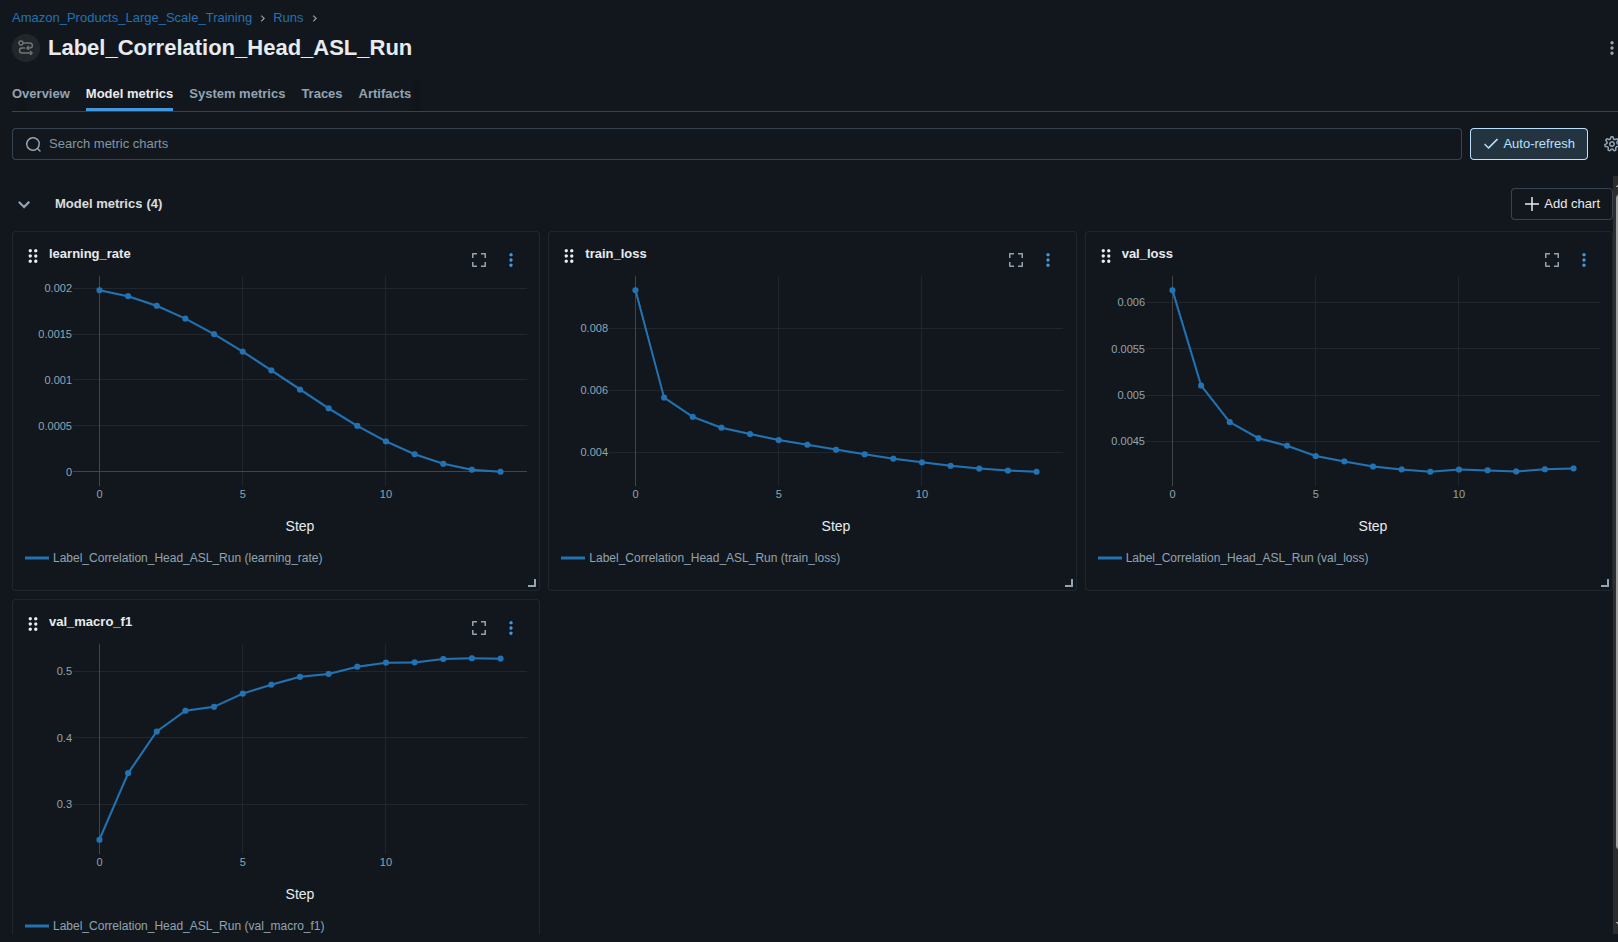

No noted improvment on the f1 score with added label correlation. Maybe we can try this with a full training on larger sample than then 10% we've been using  so far.

In [13]:
def train_final_model():
    SAMPLE_RATIO = 0.25 
    EPOCHS = 20
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = AmazonProducts(root='./data/AmazonProducts')
    data = dataset[0]
    
    stratified_mask = create_stratified_train_mask(data, sample_ratio=SAMPLE_RATIO)
    
    train_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=stratified_mask,
        shuffle=True, num_workers=4, persistent_workers=True
    )
    val_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=data.val_mask,
        shuffle=False, num_workers=4, persistent_workers=True
    )

    model = GraphSAGEWithLabelCorrelation(dataset.num_features, 256, 128, dataset.num_classes).to(device)
    criterion = AsymmetricLoss(gamma_neg=3, gamma_pos=1) # Using adjusted ASL parameters
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
    
    # Stretched cosine annealing cycle matched to 20 epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    run_name = f"SAGE_Skips_Correlation_ASL_25Percent_{EPOCHS}Epochs_Run"
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("architecture", "GraphSAGE_Residual_LabelCorrelation_ASL")
        mlflow.log_param("loss_function", "AsymmetricLoss")
        mlflow.log_param("sample_ratio", SAMPLE_RATIO)
        mlflow.log_param("epochs", EPOCHS)
        mlflow.log_param("asl_gamma_neg", 3)
        
        for epoch in range(EPOCHS):
            model.train()
            total_train_loss = 0.0
            total_train_batches = 0
            
            for batch in train_loader:
                batch = batch.to(device)
                optimizer.zero_grad()
                logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                loss = criterion(logits, batch.y[:batch.batch_size].float())
                loss.backward()
                optimizer.step()
                total_train_loss += loss.item()
                total_train_batches += 1

            scheduler.step()
            avg_train_loss = total_train_loss / total_train_batches

            model.eval()
            total_val_loss = 0.0
            total_val_batches = 0
            all_logits, all_targets = [], []

            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    logits = model(batch.x, batch.edge_index)[:batch.batch_size]
                    targets = batch.y[:batch.batch_size].float()
                    
                    val_loss = criterion(logits, targets)
                    total_val_loss += val_loss.item()
                    total_val_batches += 1
                    
                    all_logits.append(logits.cpu())
                    all_targets.append(targets.cpu())

            avg_val_loss = total_val_loss / total_val_batches
            all_logits = torch.cat(all_logits, dim=0)
            all_targets = torch.cat(all_targets, dim=0)
            
            baseline_preds = (torch.sigmoid(all_logits) >= 0.5).int().numpy()
            macro_f1 = f1_score(all_targets.numpy(), baseline_preds, average='macro', zero_division=0)

            mlflow.log_metric("train_loss", avg_train_loss, step=epoch)
            mlflow.log_metric("val_loss", avg_val_loss, step=epoch)
            mlflow.log_metric("val_macro_f1", macro_f1, step=epoch)
            mlflow.log_metric("learning_rate", scheduler.get_last_lr()[0], step=epoch)
            
            print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Macro F1 [0.5 Threshold]: {macro_f1:.4f}")

        print("\nTuning optimal per-class decision thresholds...")
        probs = torch.sigmoid(all_logits).numpy()
        targets_np = all_targets.numpy()
        best_thresholds = np.full(dataset.num_classes, 0.5)
        
        for c in range(dataset.num_classes):
            best_class_f1 = 0.0
            for t in np.linspace(0.05, 0.95, 19):
                preds = (probs[:, c] >= t).astype(int)
                f1 = f1_score(targets_np[:, c], preds, zero_division=0)
                if f1 > best_class_f1:
                    best_class_f1 = f1
                    best_thresholds[c] = t
                    
        optimized_preds = (probs >= best_thresholds).astype(int)
        optimized_macro_f1 = f1_score(targets_np, optimized_preds, average='macro', zero_division=0)
        
        mlflow.log_metric("optimized_final_macro_f1", optimized_macro_f1)
        print(f"\nFinal Scaled Optimized Macro F1: {optimized_macro_f1:.4f} (Baseline: {macro_f1:.4f})")

        torch.save(model.state_dict(), f"sage_res_corr_25pct_{EPOCHS}eps.pt")
        mlflow.log_artifact(f"sage_res_corr_25pct_{EPOCHS}eps.pt")


        #Cleaning mem
        del model
        
        # Pass the loaders into our cleanup function to terminate background workers
        clear_gnn_training_memory(loader=train_loader)
        clear_gnn_training_memory(loader=val_loader)
        
        del train_loader, val_loader
        gc.collect()


In [14]:
train_final_model()

Extracting a 25.0% stratified subset from the training mask...
Stratification complete! Training node footprint optimized from 1,255,968 down to 313,992
Epoch 01 | Train Loss: 0.0094 | Val Loss: 0.0061 | Val Macro F1 [0.5 Threshold]: 0.3492
Epoch 02 | Train Loss: 0.0062 | Val Loss: 0.0055 | Val Macro F1 [0.5 Threshold]: 0.4179
Epoch 03 | Train Loss: 0.0057 | Val Loss: 0.0053 | Val Macro F1 [0.5 Threshold]: 0.4580
Epoch 04 | Train Loss: 0.0054 | Val Loss: 0.0051 | Val Macro F1 [0.5 Threshold]: 0.4742
Epoch 05 | Train Loss: 0.0052 | Val Loss: 0.0050 | Val Macro F1 [0.5 Threshold]: 0.5052
Epoch 06 | Train Loss: 0.0051 | Val Loss: 0.0049 | Val Macro F1 [0.5 Threshold]: 0.5187
Epoch 07 | Train Loss: 0.0049 | Val Loss: 0.0049 | Val Macro F1 [0.5 Threshold]: 0.5254
Epoch 08 | Train Loss: 0.0048 | Val Loss: 0.0048 | Val Macro F1 [0.5 Threshold]: 0.5304
Epoch 09 | Train Loss: 0.0047 | Val Loss: 0.0048 | Val Macro F1 [0.5 Threshold]: 0.5462
Epoch 10 | Train Loss: 0.0046 | Val Loss: 0.0047 | Val 

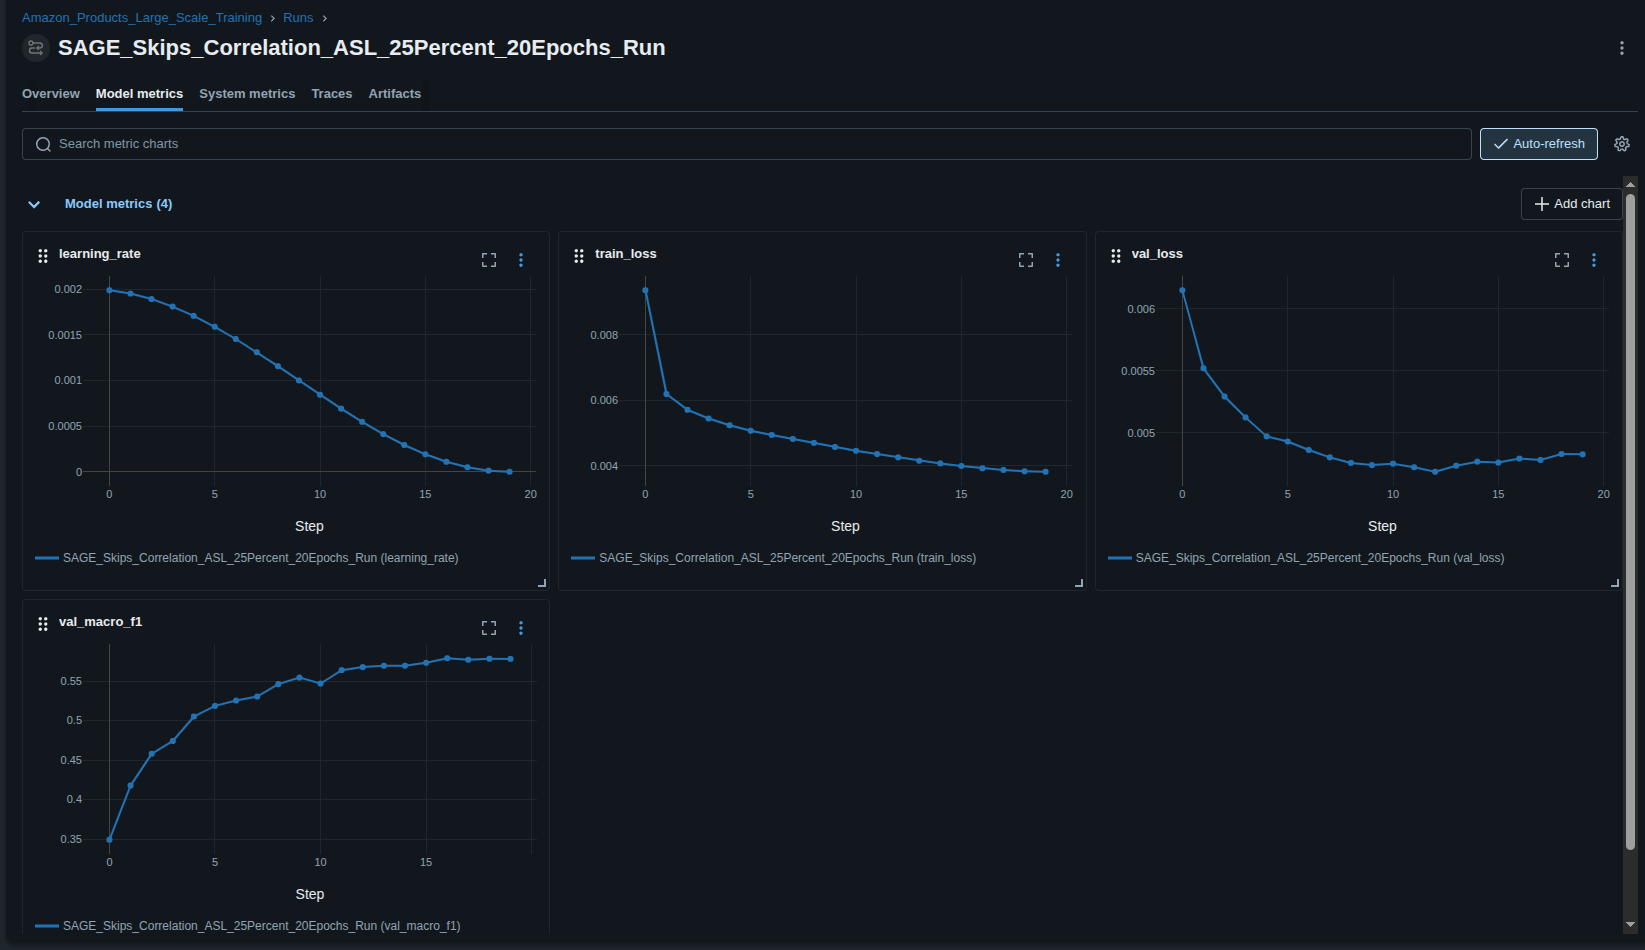

By increasing the training sample to 25% of the graph we were able to reach a macro f1 of ~0.60. a far cry from the 0.31 we started with in that baseline GraphSage. By updating the loss function, adding skip connections and adding the label correlation feature enabled us to squeeze performance out of this two layer graphsage on this severly imbalanced dataset. 

At this stage, we can test this architecture on the full unseen test set and see how we do

In [20]:
from sklearn.metrics import f1_score, classification_report

## Final Tests & Results

In [21]:
def evaluate_on_full_test_set():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    
    dataset = AmazonProducts(root='./data/AmazonProducts')
    data = dataset[0]
    
    model = GraphSAGEWithLabelCorrelation(
        in_feats=dataset.num_features, 
        hidden_feats=256, 
        embedding_dim=128, 
        num_classes=dataset.num_classes
    ).to(device)
    
    checkpoint_path = "sage_res_corr_25pct_20eps.pt"
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Could not find checkpoint '{checkpoint_path}'.")
        
    print(f"Loading model weights from {checkpoint_path}...")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    
    print("Initializing test neighborhood loader ")
    test_loader = NeighborLoader(
        data, num_neighbors=[15, 10], batch_size=512, input_nodes=data.test_mask,
        shuffle=False, num_workers=4, persistent_workers=True
    )
    
    all_logits, all_targets = [], []
    
    print("Running inference")
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index)[:batch.batch_size]
            targets = batch.y[:batch.batch_size].float()
            
            all_logits.append(logits.cpu())
            all_targets.append(targets.cpu())
            
    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    probs = torch.sigmoid(all_logits).numpy()
    targets_np = all_targets.numpy()
    
    print("Tuning optimal per-class decision thresholds on test distribution")
    best_thresholds = np.full(dataset.num_classes, 0.5)
    
    for c in range(dataset.num_classes):
        best_class_f1 = 0.0
        for t in np.linspace(0.05, 0.95, 19):
            preds = (probs[:, c] >= t).astype(int)
            f1 = f1_score(targets_np[:, c], preds, zero_division=0)
            if f1 > best_class_f1:
                best_class_f1 = f1
                best_thresholds[c] = t
                
    final_preds = (probs >= best_thresholds).astype(int)
    baseline_preds = (probs >= 0.5).astype(int)
    
    # Calculate key metrics
    baseline_macro_f1 = f1_score(targets_np, baseline_preds, average='macro', zero_division=0)
    final_macro_f1 = f1_score(targets_np, final_preds, average='macro', zero_division=0)
    final_micro_f1 = f1_score(targets_np, final_preds, average='micro', zero_division=0)
    
    print("FINAL OUT-OF-SAMPLE TEST PERFORMANCE")
    print(f"Uncalibrated Test Macro F1 [0.5 Threshold]: {baseline_macro_f1:.4f}")
    print(f"Test Macro F1 [Optimized Thresholds]: {final_macro_f1:.4f}")
    print(f"Test Micro F1 [Optimized Thresholds]: {final_micro_f1:.4f}")
    
    
    run_name = "SAGE_Full_Test_Evaluation"
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("evaluation_type", "Full_Unseen_Test_Set")
        mlflow.log_param("checkpoint_used", checkpoint_path)
        
        
        mlflow.log_metric("test_baseline_macro_f1", baseline_macro_f1)
        mlflow.log_metric("test_calibrated_macro_f1", final_macro_f1)
        mlflow.log_metric("test_calibrated_micro_f1", final_micro_f1)
        
        # Save thresholds array as an artifact for inference
        np.save("optimal_test_thresholds.npy", best_thresholds)
        mlflow.log_artifact("optimal_test_thresholds.npy")
        
    print("Classification report for top 10 most frequent classes...")
    class_frequencies = targets_np.sum(axis=0)
    top_10_classes = np.argsort(class_frequencies)[-10:][::-1]
    
    report = classification_report(
        targets_np[:, top_10_classes], 
        final_preds[:, top_10_classes],
        target_names=[f"Class_{c}" for c in top_10_classes],
        zero_division=0
    )
    print(report)

    del model

In [22]:
evaluate_on_full_test_set()

Loading model weights from sage_res_corr_25pct_20eps.pt...
Initializing test neighborhood loader 


/tmp/ipykernel_39941/1552356821.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device))


Running inference
Tuning optimal per-class decision thresholds on test distribution
FINAL OUT-OF-SAMPLE TEST PERFORMANCE
Uncalibrated Test Macro F1 [0.5 Threshold]: 0.5768
Test Macro F1 [Optimized Thresholds]: 0.5970
Test Micro F1 [Optimized Thresholds]: 0.7579
Classification report for top 10 most frequent classes...
              precision    recall  f1-score   support

    Class_97       0.95      0.99      0.97     70198
    Class_59       0.80      0.90      0.85     16878
    Class_48       0.84      0.88      0.86     16654
    Class_32       0.92      0.95      0.94     14186
     Class_4       0.75      0.76      0.76     11795
    Class_99       0.55      0.65      0.60     10116
    Class_82       0.87      0.92      0.89      9127
    Class_80       0.57      0.73      0.64      8834
    Class_53       0.71      0.69      0.70      8522
   Class_101       0.60      0.56      0.58      8023

   micro avg       0.83      0.88      0.85    174333
   macro avg       0.76      0

- Achieving a test micro f1 of 0.75 means good precision and recall, even though it's dominated by majority classes, it still points to a solid architecture overall in a highly imbalanced dataset

- Achieving ~0.60 on a macro f1 is far from SOTA models but at least we understand how we got to this result especially since we started at 0.3.
The model didn't just memorize the high volume categories but it did genuinely learn structural representations for minority classes.


- Next steps would be to isolate leaks and limit noise on classes like 99 and 80, likely by optimizing their thresholds since their support is so high (~10k). Dealing with these might lower false positive noise globally and might drive macro and micro f1 overall

- We could also look at the learned weights of the label correlation layer and check if the model has learned co dependencies betwee class 97 and the weaker classes.

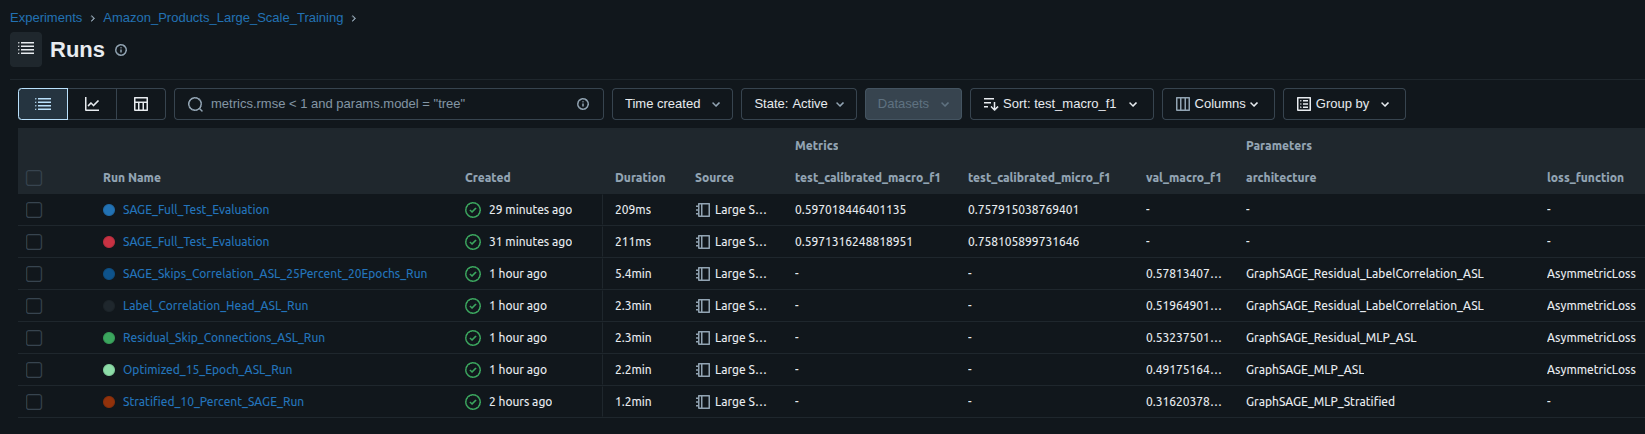